In [1]:
import os
import json
import pandas as pd
from PIL import Image

## Summary

In [2]:
dataset_name = ["200k_live_face_dataset","inswapper_rev","evaluation_indonesian_deepfake_dataset_v2_updated"]
path_json = os.path.join("result_"+dataset_name[0]+".json")

In [3]:
with open(path_json, 'r') as file:
    data = json.load(file)

In [4]:
list_values = list(data.values())

In [5]:
df_result = pd.DataFrame(data.values())
print(df_result.shape)
df_result.head(5)

(252901, 12)


,label,method,processed_path,landmarks_path,mask_path,angle,status,pred_age,score_blur_face,score_dark,score_blur_img,score_dfd1-0-0
0,0,production_live,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,0,FACE DETECTED,10-19,64.372249,6.042600,30.311902,0.052733
1,0,production_live,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,0,FACE DETECTED,10-19,31.407137,24.150342,18.798452,0.684331
2,0,production_live,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,0,FACE DETECTED,60-69,43.922542,7.644977,27.055521,0.574708
3,0,production_live,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,0,FACE DETECTED,20-29,72.660813,8.684359,30.809624,0.001131
4,0,production_live,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,/mnt/ssd/datasets/deepfake/200k_live_face_data...,0,FACE DETECTED,20-29,48.377259,14.896691,24.768304,0.021222


In [6]:
df_incorrect = df_result[df_result["label"]!=(df_result["score_dfd1-0-0"]>=0.5)]
df_incorrect.mean()

/tmp/ipykernel_29558/2108809730.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_incorrect.mean()


label               0.000000
angle               0.000000
score_blur_face    45.369280
score_dark         15.469505
score_blur_img     32.297277
score_dfd1-0-0      0.721865
dtype: float64

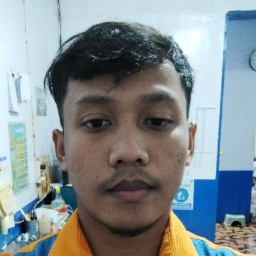

In [7]:
Image.open(df_incorrect.iloc[0]["processed_path"])

label                                                              0
method                                               production_live
processed_path     /mnt/ssd/datasets/deepfake/200k_live_face_data...
landmarks_path     /mnt/ssd/datasets/deepfake/200k_live_face_data...
mask_path          /mnt/ssd/datasets/deepfake/200k_live_face_data...
angle                                                              0
status                                                 FACE DETECTED
pred_age                                                       10-19
score_blur_face                                             41.12296
score_dark                                                  1.678267
score_blur_img                                               36.3073
score_dfd1-0-0                                              0.988764
Name: 745, dtype: object


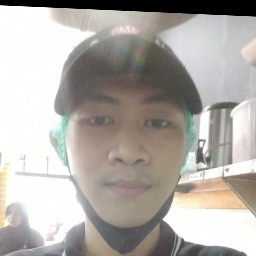

In [8]:
print(df_incorrect.iloc[50])
Image.open(df_incorrect.iloc[50]["processed_path"])

In [ ]:
df_correct = df_result[df_result["label"]==(df_result["score_dfd1-0-0"]>=0.5)]
print(df_correct["label"].count())
df_correct.mean()

237589


In [24]:
print((df_result["label"]==(df_result["score_dfd1-0-0"]>=0.5)).count())
print((df_result["label"]==(df_result["score_dfd1-0-0"]>=0.5)).sum())
#.head(5)

3801
3666


## Get Method

In [23]:
list_dataset_name = ["200k_live_face_dataset","inswapper_rev","evaluation_indonesian_deepfake_dataset_v2_updated",
                     "faceforensics++_train"]
dataset_name = list_dataset_name[-1]
path_json = os.path.join("result_"+dataset_name+".json")
with open(path_json, 'r') as file:
    data = json.load(file)

In [24]:
df_result = pd.DataFrame(data.values())
df_result["dataset"] = dataset_name

In [25]:
df_result.iloc[0]["processed_path"]

'/mnt/ssd/datasets/deepfake/FaceForensics++/manipulated_sequences/Deepfakes/c23/frames/071_054/087.png'

In [26]:
def get_method(row):
    dataset = row['dataset']
    img_path = str(row.get('image_path',row.get('processed_path')))
    if 'reswapper' in dataset.lower():
        method = 'reswapperv2'
        return method
    elif 'ffhq' in dataset.lower():
        method = 'ffhq'
        return method
    elif '200k_live_face_dataset' in dataset.lower():
        method = 'production_live'
        return method
    elif 'indonesian_deepfake_dataset_v2' in dataset.lower():
        id_dataset = img_path.split('/').index('indonesian_deepfake_dataset_v2_test')
        method = "verification" if img_path.split('/')[id_dataset+3] == 'live' else 'deepfake'
        return method
    elif 'df40' in dataset.lower():
        id_dataset = img_path.lower().split('/').index('df40')
        method = img_path.split('/')[id_dataset+3].lower()
        return method
    elif 'inswapper' in dataset.lower():
        id_dataset = img_path.lower().split('/').index('inswapper')
        method = img_path.split('/')[id_dataset+4]
            
        return method
    elif 'faceforensics++' in dataset.lower():
        id_dataset = img_path.lower().split('/').index('faceforensics++')
        method = img_path.split('/')[id_dataset+2]
        return method
        
    else:
        folder_lvone = img_path.split('/')[7]
        #if dataset=='indonesian_deepfake_dataset_v2':
        #    if folder_lvone == 'live':
        #        #method = ';'.join([folder_lvone,"verification"])
        #        method = "verification"
        #    elif folder_lvone == 'deepfake':
        #        #method = ';'.join([folder_lvone,img_path.split('/')[8]])
        #        method = img_path.split('/')[8]
        #    return method
        if 'facebook_dfdc' in dataset.lower():
            #if folder_lvone == 'live':
            #    #method = ';'.join([folder_lvone,"verification"])
            #    method = "verification"
            #elif folder_lvone == 'deepfake':
            #    #method = ';'.join([folder_lvone,img_path.split('/')[8]])
            method = 'facebook_dfdc'
            return method
        elif 'vh_production_face_deepfake_v1_eval' in dataset.lower():
            method = img_path.split('/')[9]
            return method
        elif 'bing_crawl' in dataset.lower():
            method = 'bing_crawl'
            return method
        elif 'client' in dataset.lower():
            method = 'client'
            return method
        

In [27]:
#df_result.head(5)
df_now = df_result
df_now['method_v2'] = df_now.apply(get_method,axis=1)
df_now.head(5)

,label,method,processed_path,angle,status,pred_age,score_blur_face,score_dark,score_blur_img,score_dfd1-0-0,dataset,method_v2
0,1,Deepfakes,/mnt/ssd/datasets/deepfake/FaceForensics++/man...,0,FACE DETECTED,10-19,45.374871,21.359483,44.306733,0.999974,faceforensics++_train,Deepfakes
1,1,Deepfakes,/mnt/ssd/datasets/deepfake/FaceForensics++/man...,0,FACE DETECTED,10-19,49.524675,20.196137,42.402112,0.999991,faceforensics++_train,Deepfakes
2,1,Deepfakes,/mnt/ssd/datasets/deepfake/FaceForensics++/man...,0,FACE DETECTED,10-19,47.882295,19.520416,40.713430,0.999738,faceforensics++_train,Deepfakes
3,1,Deepfakes,/mnt/ssd/datasets/deepfake/FaceForensics++/man...,0,FACE DETECTED,30-39,51.612918,22.215577,42.440997,0.999955,faceforensics++_train,Deepfakes
4,1,Deepfakes,/mnt/ssd/datasets/deepfake/FaceForensics++/man...,0,FACE DETECTED,10-19,46.257823,23.523775,40.661367,0.999485,faceforensics++_train,Deepfakes


In [28]:
df_now.groupby('method_v2').count()

,label,method,processed_path,angle,status,pred_age,score_blur_face,score_dark,score_blur_img,score_dfd1-0-0,dataset
method_v2,,,,,,,,,,,
Deepfakes,22928,22928,22928,22928,22928,22928,22928,22928,22928,22928,22928
Face2Face,22991,22991,22991,22991,22991,22991,22991,22991,22991,22991,22991
FaceShifter,22968,22968,22968,22968,22968,22968,22968,22968,22968,22968,22968
FaceSwap,22999,22999,22999,22999,22999,22999,22999,22999,22999,22999,22999
NeuralTextures,22973,22973,22973,22973,22973,22973,22973,22973,22973,22973,22973
youtube,9342,9342,9342,9342,9342,9342,9342,9342,9342,9342,9342
